<a href="https://colab.research.google.com/github/janhavipatkar854/CSL701-CS42-Machine-Learning-Lab/blob/main/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Janhavi n Patkar

Batch : CS 03


Roll Number : CS 42



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [1]:
# Import core Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn
import sklearn

# Display library versions (optional)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

# Load the dataset
df = pd.read_csv("data.csv")

# Display the first five rows
print("\nFirst five rows of the dataset:")
display(df.head())

# Display dataset dimensions
print("\nDataset shape:", df.shape)

# Display column names and data types
print("\nDataset information:")
df.info()

NumPy version: 2.1.3
Pandas version: 2.2.3
Scikit-learn version: 1.6.1

First five rows of the dataset:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Dataset shape: (569, 33)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non

# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset shape: (569, 33)

--- Column Data Types ---
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
com

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



--- Diagnosis Class Distribution ---
diagnosis
B    357
M    212
Name: count, dtype: int64

--- Diagnosis Class Percentages ---
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


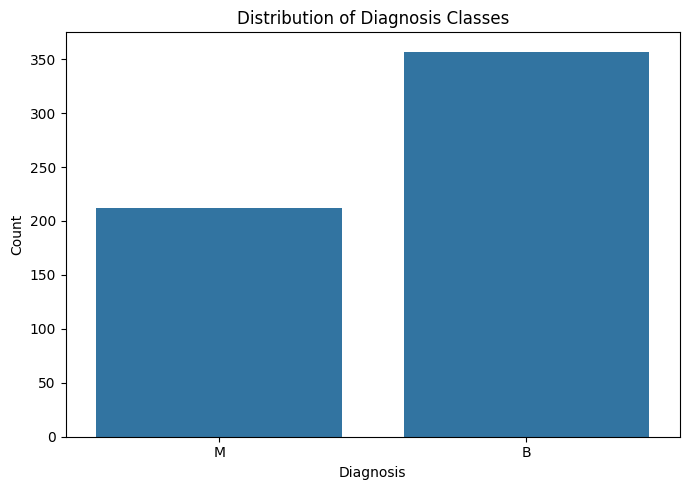

In [2]:
# 1. Check the dataset dimensions
print("Dataset shape:", df.shape)

# 2. Check column names and data types
print("\n--- Column Data Types ---")
print(df.dtypes)

# 3. Check missing values in each column
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

# 4. Generate summary statistics
print("\n--- Summary Statistics ---")
display(df.describe())

# 5. Inspect target class distribution
print("\n--- Diagnosis Class Distribution ---")
print(df["diagnosis"].value_counts())

# 6. Display class percentages
print("\n--- Diagnosis Class Percentages ---")
print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))

# 7. Visualize diagnosis distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribution of Diagnosis Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [3]:
# 1. Drop unnecessary metadata columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# 2. Convert diagnosis into numerical values
# M (Malignant) = 1
# B (Benign) = 0
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# 3. Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# 4. Verify the results
print("Feature matrix shape (X):", X.shape)
print("Target vector shape (y):", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget class distribution:")
print(y.value_counts())

print("\nMissing values in target:", y.isnull().sum())

# 5. Display sample data
print("\nFirst five rows of features:")
display(X.head())

print("\nFirst five target labels:")
display(y.head())

Feature matrix shape (X): (569, 30)
Target vector shape (y): (569,)

Feature columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target class distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Missing values in target: 0

First five rows of features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First five target labels:


,diagnosis
0,1
1,1
2,1
3,1
4,1


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [4]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Verify the results
print("Scaled feature matrix shape:", X_scaled.shape)

print("\nMean of the first 5 scaled features:")
print(X_scaled.mean().head().round(6))

print("\nStandard deviation of the first 5 scaled features:")
print(X_scaled.std(ddof=0).head().round(6))

# Display the first five rows
print("\nFirst five rows of standardized features:")
display(X_scaled.head())

Scaled feature matrix shape: (569, 30)

Mean of the first 5 scaled features:
radius_mean       -0.0
texture_mean       0.0
perimeter_mean    -0.0
area_mean         -0.0
smoothness_mean   -0.0
dtype: float64

Standard deviation of the first 5 scaled features:
radius_mean        1.0
texture_mean       1.0
perimeter_mean     1.0
area_mean          1.0
smoothness_mean    1.0
dtype: float64

First five rows of standardized features:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [5]:
# Import PCA
from sklearn.decomposition import PCA

# Initialize PCA to reduce 30 features to 2 components
pca = PCA(n_components=2)

# Transform standardized features into 2D
X_pca = pca.fit_transform(X_scaled)

# Convert the result into a DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

# Add diagnosis labels for visualization
pca_df["diagnosis"] = y

# Display the first five rows
print("First five rows of PCA-transformed data:")
display(pca_df.head())

# Check the new dimensions
print("\nPCA data shape:", X_pca.shape)

# Calculate explained variance
print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:")
print(f"{pca.explained_variance_ratio_.sum() * 100:.2f}%")

First five rows of PCA-transformed data:


,PC1,PC2,diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1



PCA data shape: (569, 2)

Explained variance ratio:
[0.44272026 0.18971182]

Total variance explained by 2 components:
63.24%


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [6]:
# Get the explained variance ratio for each principal component
explained_variance = pca.explained_variance_ratio_

# Calculate cumulative variance retained
cumulative_variance = np.cumsum(explained_variance)

# Print individual explained variance
print(f"Variance explained by PC1: {explained_variance[0]:.4f} "
      f"({explained_variance[0] * 100:.2f}%)")

print(f"Variance explained by PC2: {explained_variance[1]:.4f} "
      f"({explained_variance[1] * 100:.2f}%)")

# Print cumulative variance
print(f"Cumulative variance retained: {cumulative_variance[-1]:.4f} "
      f"({cumulative_variance[-1] * 100:.2f}%)")

# Display results in a DataFrame
variance_df = pd.DataFrame({
    "Principal Component": ["PC1", "PC2"],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance (%)": explained_variance * 100,
    "Cumulative Variance (%)": cumulative_variance * 100
})

display(variance_df.round(4))

Variance explained by PC1: 0.4427 (44.27%)
Variance explained by PC2: 0.1897 (18.97%)
Cumulative variance retained: 0.6324 (63.24%)


,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.4427,44.2720,44.2720
1,PC2,0.1897,18.9712,63.2432


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

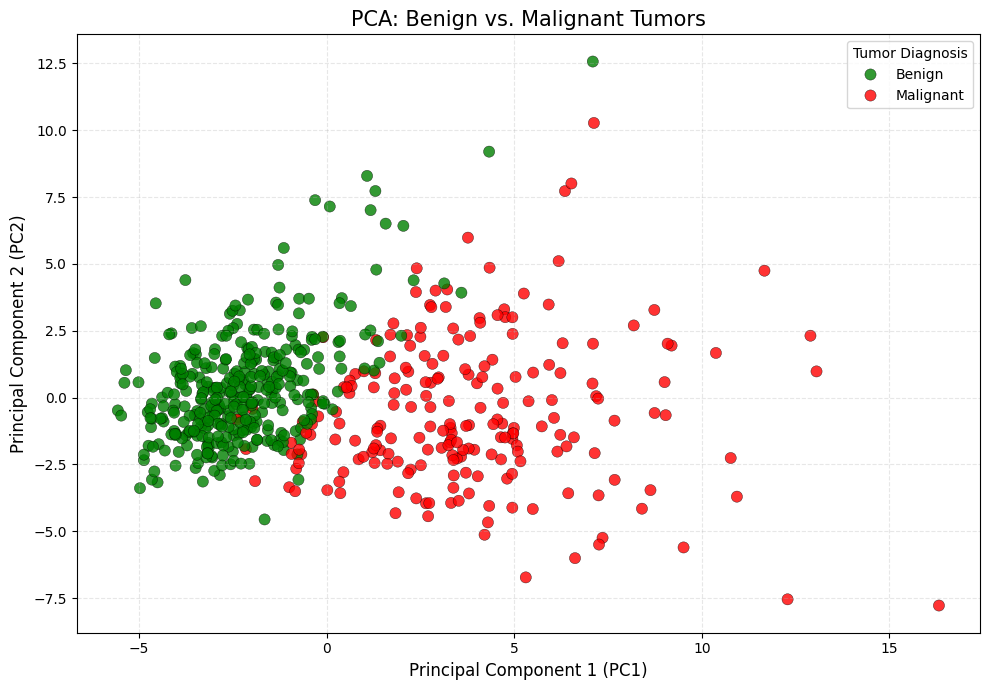

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame containing PCA components and diagnosis labels
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=y.index
)

# Map numerical labels to diagnosis names
pca_df["Diagnosis"] = y.map({
    0: "Benign",
    1: "Malignant"
})

# Create the PCA scatter plot
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    hue_order=["Benign", "Malignant"],
    palette={
        "Benign": "green",
        "Malignant": "red"
    },
    s=65,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.3
)

# Add plot details
plt.title("PCA: Benign vs. Malignant Tumors", fontsize=15)
plt.xlabel("Principal Component 1 (PC1)", fontsize=12)
plt.ylabel("Principal Component 2 (PC2)", fontsize=12)
plt.legend(title="Tumor Diagnosis")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [8]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Split the original 30-feature dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

# 2. Standardize using training data only
scaler_lr = StandardScaler()

X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

# 3. Train Logistic Regression model
lr_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# 4. Generate predictions
y_pred = lr_model.predict(X_test_scaled)

# 5. Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n--- Logistic Regression Baseline Performance ---")
print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

print("\nConfusion Matrix:")
print(cm)

# 7. Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

Training features shape: (455, 30)
Testing features shape: (114, 30)

--- Logistic Regression Baseline Performance ---
Accuracy:  0.9649 (96.49%)
Precision: 0.9750
Recall:    0.9286
F1-score:  0.9512

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [9]:
# Import required libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. Create the PCA feature matrix (2 components)
X_pca_2d = pca_df[["PC1", "PC2"]]

# 2. Split PCA data into training and testing sets
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_2d,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("PCA training set shape:", X_train_pca.shape)
print("PCA testing set shape:", X_test_pca.shape)

# 3. Initialize and train Logistic Regression
lr_pca_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

lr_pca_model.fit(X_train_pca, y_train_pca)

# 4. Make predictions
y_pred_pca = lr_pca_model.predict(X_test_pca)

# 5. Evaluate model performance
print("\n--- Logistic Regression on PCA Data ---")

print(f"Accuracy:  {accuracy_score(y_test_pca, y_pred_pca):.4f}")
print(f"Precision: {precision_score(y_test_pca, y_pred_pca, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test_pca, y_pred_pca, zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test_pca, y_pred_pca, zero_division=0):.4f}")

# 6. Display confusion matrix
cm_pca = confusion_matrix(
    y_test_pca,
    y_pred_pca,
    labels=[0, 1]
)

print("\nConfusion Matrix:")
print(cm_pca)

# 7. Detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

PCA training set shape: (455, 2)
PCA testing set shape: (114, 2)

--- Logistic Regression on PCA Data ---
Accuracy:  0.9386
Precision: 0.9730
Recall:    0.8571
F1-score:  0.9114

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



========== ACCURACY COMPARISON ==========
Before PCA (30 features): 0.9649 (96.49%)
After PCA (2 components): 0.9386 (93.86%)


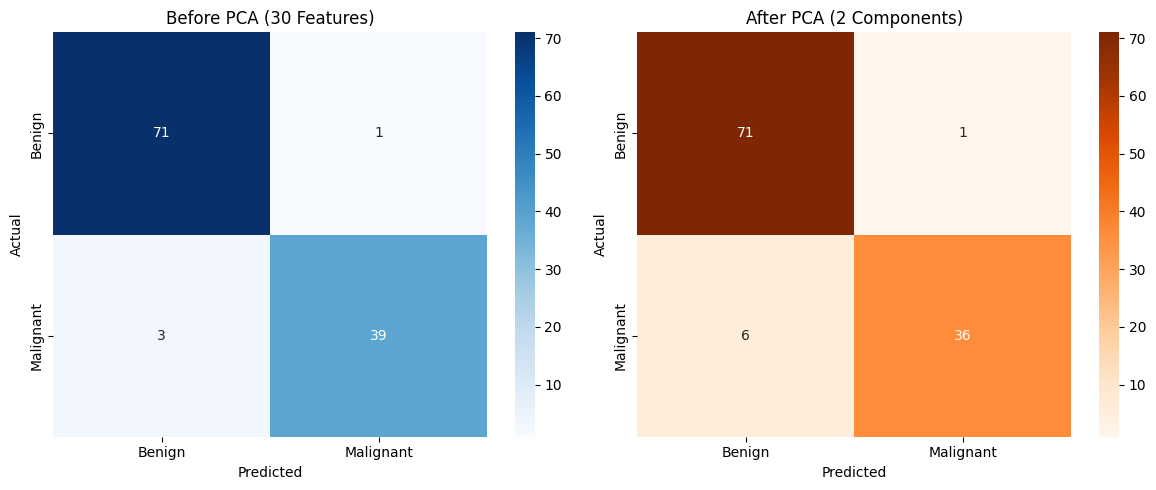


========== BEFORE PCA: CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


========== AFTER PCA: CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


========== PERFORMANCE SUMMARY ==========


,Metric,Before PCA (30 features),After PCA (2 components)
0,Accuracy,0.9649,0.9386
1,Precision (Malignant),0.9750,0.9730
2,Recall (Malignant),0.9286,0.8571
3,F1-score (Malignant),0.9512,0.9114


In [10]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions from both models
# Raw 30-feature model from Task 8
y_pred_raw = lr_model.predict(X_test_scaled)

# PCA 2-component model from Task 9
y_pred_pca = lr_pca_model.predict(X_test_pca)

# 2. Calculate accuracy scores
accuracy_raw = accuracy_score(y_test, y_pred_raw)
accuracy_pca = accuracy_score(y_test_pca, y_pred_pca)

print("========== ACCURACY COMPARISON ==========")
print(f"Before PCA (30 features): {accuracy_raw:.4f} "
      f"({accuracy_raw * 100:.2f}%)")
print(f"After PCA (2 components): {accuracy_pca:.4f} "
      f"({accuracy_pca * 100:.2f}%)")

# 3. Display confusion matrices
cm_raw = confusion_matrix(y_test, y_pred_raw, labels=[0, 1])
cm_pca = confusion_matrix(y_test_pca, y_pred_pca, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_raw, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[0]
)
axes[0].set_title("Before PCA (30 Features)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_pca, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=axes[1]
)
axes[1].set_title("After PCA (2 Components)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 4. Classification reports
print("\n========== BEFORE PCA: CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test,
    y_pred_raw,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

print("\n========== AFTER PCA: CLASSIFICATION REPORT ==========")
print(classification_report(
    y_test_pca,
    y_pred_pca,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# 5. Create a concise metric comparison table
report_raw = classification_report(
    y_test, y_pred_raw,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

report_pca = classification_report(
    y_test_pca, y_pred_pca,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    output_dict=True,
    zero_division=0
)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Malignant)",
               "Recall (Malignant)", "F1-score (Malignant)"],
    "Before PCA (30 features)": [
        accuracy_raw,
        report_raw["Malignant"]["precision"],
        report_raw["Malignant"]["recall"],
        report_raw["Malignant"]["f1-score"]
    ],
    "After PCA (2 components)": [
        accuracy_pca,
        report_pca["Malignant"]["precision"],
        report_pca["Malignant"]["recall"],
        report_pca["Malignant"]["f1-score"]
    ]
})

print("\n========== PERFORMANCE SUMMARY ==========")
display(comparison.round(4))

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.